## Calculation of Markers

In [25]:
# import necessary libraries
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import re
from typing import Dict, List, Tuple, Any

### 1. Reading the data file and extracting metadata from the header

In [ ]:
# File paths
data_path = "../data/002MoDe_R1.csv"
marker_path = "../data/002MoDe_R1.marker.csv"

In [27]:
def parse_header(data_path: str) -> Dict[str, Any]:
    """Parses the header from the first non-empty line of the data file."""
    header: Dict[str, Any] = {}
    try:
        with open(data_path, "r", encoding="utf-8") as f:
            first_line = ""
            for line in f:
                stripped_line = line.strip()
                if stripped_line:
                    first_line = stripped_line
                    break

            if not first_line:
                return header

            for part in first_line.split(";"):
                part = part.strip()
                if not part:
                    continue

                if "=" in part:
                    k, v = part.split("=", 1)
                elif ":" in part:
                    k, v = part.split(":", 1)
                else:
                    tokens = part.split()
                    k = tokens[0]
                    v = tokens[1] if len(tokens) > 1 else ""

                k, v = k.strip(), v.strip()
                try:
                    header[k] = float(v)
                except (ValueError, TypeError):
                    header[k] = v

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return {}

    return header

### 2. Extracting start and end timestamps from the marker file

In [28]:
def parse_markers(marker_path: str) -> Dict[str, Any]:
    """Reads a marker file to extract record start and end timestamps."""
    record_starts_raw: List[int] = []
    record_ends_raw: List[int] = []
    all_markers: List[Tuple[int, str]] = []

    try:
        with open(marker_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
    except FileNotFoundError:
        raise FileNotFoundError(f"Marker file not found at {marker_path}")

    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 2:
            continue

        ts_str = parts[1].strip().replace(" ", "")
        try:
            ts = int(ts_str)
        except ValueError:
            continue

        all_markers.append((ts, line.strip()))

        if "DoCycleChange:DoRecord" in line:
            record_starts_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_ends_raw.append(ts)

    if not record_starts_raw:
        raise ValueError("No 'DoRecord' events detected in the marker file.")
    if not record_ends_raw:
        raise ValueError("No 'DoPause' events detected in the marker file.")

    record_starts_raw.sort()
    record_ends_raw.sort()

    pairs: List[Tuple[int, int]] = []
    end_idx = 0
    for start_ts in record_starts_raw:
        while end_idx < len(record_ends_raw) and record_ends_raw[end_idx] < start_ts:
            end_idx += 1
        if end_idx < len(record_ends_raw):
            pairs.append((start_ts, record_ends_raw[end_idx]))
            end_idx += 1
        else:
            break

    if not pairs:
        raise RuntimeError("No valid start/end pairs found in markers.")

    return {
        "start_ts": [p[0] for p in pairs],
        "end_ts": [p[1] for p in pairs],
        "pairs": pairs,
        "all_markers": all_markers,
    }

In [29]:
def load_data(data_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads the time-series data from the CSV file."""
    timestamps: List[float] = []
    mouse_x: List[float] = []
    mouse_y: List[float] = []
    in_target: List[int] = []

    try:
        with open(data_path, "r", encoding="utf-8") as f:
            # Skip header lines until a data row is found
            for line in f:
                if (
                    line.strip()
                    and re.match(r"^-?\d+", line.strip().split(";")[0].split(",")[0])
                ):
                    parts = line.strip().split(";")[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            pass
                    break

            # Continue reading the rest of the file
            reader = csv.reader(f, delimiter=";")
            for row in reader:
                if len(row) >= 1 and "," in row[0]:
                    parts = row[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            continue

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return np.array([]), np.array([]), np.array([]), np.array([])

    return (
        np.array(timestamps),
        np.array(mouse_x),
        np.array(mouse_y),
        np.array(in_target),
    )

## Function to plot raw time series

In [30]:
def plot_overall_timeseries(
    time: np.ndarray,
    mouse_x: np.ndarray,
    mouse_y: np.ndarray,
    record_starts_sec: List[float],
    record_ends_sec: List[float],
) -> None:
    """Plot raw time series"""
    # Centrer les données
    plot_x = mouse_x - np.mean(mouse_x)
    plot_y = mouse_y - np.mean(mouse_y)

    # Masque des intervalles valides
    valid_mask = np.zeros_like(time, dtype=bool)
    for start, end in zip(record_starts_sec, record_ends_sec):
        valid_mask |= (time >= start) & (time <= end)

    plot_x_masked = np.copy(plot_x)
    plot_y_masked = np.copy(plot_y)
    plot_x_masked[~valid_mask] = np.nan
    plot_y_masked[~valid_mask] = np.nan

    plt.figure(figsize=(15, 6))
    plt.plot(time, plot_x_masked, ".", ms=4, color="tab:blue", label="x position")
    plt.plot(time, plot_y_masked, ".", ms=4, color="tab:orange", label="y position")

    for i, s in enumerate(record_starts_sec):
        plt.axvline(
            s,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="record start" if i == 0 else "",
        )

    for i, e in enumerate(record_ends_sec):
        plt.axvline(
            e,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="record end" if i == 0 else "",
        )

    plt.xlim(
        min(time[0], record_starts_sec[0]) - 1,
        max(time[-1], record_ends_sec[-1]) + 1,
    )
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Raw time series data")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

## Function to plot the trajectory

In [31]:
def plot_record_trajectory(
    record_idx: int,
    data: Dict[str, np.ndarray],
    header: Dict[str, Any],
) -> None:
    """Plot the spatial cursor trajectory for a single recording.

    The figure shows:
    - The continuous cursor trajectory (steel-blue line).
    - Sample points classified as:
      - inside the target (green dots),
      - outside the target (red dots).
    - The target ring, drawn as a yellow annulus centered at (0, 0),
      using `externalRadius` and `internalRadius` from the header.
    - The screen border, drawn as a magenta rectangle, using `screenWidth`
      and `screenHeight` from the header.
    - A custom legend that distinguishes:
      - screen border,
      - target area,
      - inside samples,
      - outside samples.

    The axes are set to an equal aspect ratio so that spatial relationships
    are not distorted.

    Parameters
    ----------
    record_idx : int
        Index of the record (trial) to display, used in the plot title.
    data : Dict[str, np.ndarray]
        Dictionary containing trajectory data for this record. Must include:
        - "x": cursor x-coordinates in pixels.
        - "y": cursor y-coordinates in pixels.
        - "in_target": binary array equal to 1 when the cursor is inside
          the target and 0 otherwise.
    header : Dict[str, Any]
        Dictionary of header values parsed from the data file. Expected keys:
        - "externalRadius": outer radius of the target ring (pixels).
        - "internalRadius": inner radius of the target ring (pixels).
        - "screenWidth": width of the screen (pixels).
        - "screenHeight": height of the screen (pixels).

    Returns
    -------
    None
        The function creates and shows a matplotlib figure, and does not
        return any value.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    x_task, y_task, in_task = data["x"], data["y"], data["in_target"]

    # Trajectoire + points
    ax.plot(x_task, y_task, "-", color="steelblue", zorder=2, lw=0.5)
    ax.scatter(
        x_task[in_task == 1],
        y_task[in_task == 1],
        color="green",
        s=10,
        zorder=3,
        lw=0.3,
    )
    ax.scatter(
        x_task[in_task == 0],
        y_task[in_task == 0],
        color="red",
        s=10,
        zorder=3,
        lw=0.8,
    )

    # Target ring (comme avant)
    circle_outer = plt.Circle(
        (0, 0),
        header.get("externalRadius", 0),
        color="yellow",
        alpha=0.5,
        zorder=1,
    )
    circle_inner = plt.Circle(
        (0, 0),
        header.get("internalRadius", 0),
        color="white",
        zorder=1,
    )
    ax.add_patch(circle_outer)
    ax.add_patch(circle_inner)

    # Screen border (comme avant)
    sw, sh = header.get("screenWidth", 0), header.get("screenHeight", 0)
    ax.plot(
        [-sw / 2, sw / 2, sw / 2, -sw / 2, -sw / 2],
        [-sh / 2, -sh / 2, sh / 2, sh / 2, -sh / 2],
        color="magenta",
        lw=1.2,
        zorder=0,
    )

    # Légende personnalisée
    screen_leg = Patch(
        facecolor="none",
        edgecolor="magenta",
        linewidth=1.2,
        label="screen",
    )
    # Target dans la légende : jaune plein, sans contour noir
    target_leg = Patch(
        facecolor="yellow",
        edgecolor="yellow",
        linewidth=0,
        label="target",
    )
    inside_leg = Line2D(
        [0],
        [0],
        marker="o",
        color="green",
        linestyle="None",
        markersize=4,
        label="inside",
    )
    outside_leg = Line2D(
        [0],
        [0],
        marker="o",
        color="red",
        linestyle="None",
        markersize=4,
        label="outside",
    )

    ax.legend(
        handles=[screen_leg, target_leg, inside_leg, outside_leg],
        loc="upper right",
    )

    ax.set_title(f"Record {record_idx} - Spatial Trajectory")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    ax.axis("equal")
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.show()


## Function to plot the 3 subplots

In [32]:
def plot_record_temporal(record_idx: int, data: Dict[str, np.ndarray]) -> None:
    """Temporal plots (X, Y, is_inside) pour un record."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Record {record_idx} — Temporal Signals")

    t_task, x_task, y_task, in_task = (
        data["time"],
        data["x"],
        data["y"],
        data["in_target"],
    )

    # X Position
    axes[0].plot(
        t_task,
        x_task,
        linestyle="-",
        marker="o",
        color="blue",
        label="x",
        lw=0.5,
        markersize=2,
    )
    axes[0].set_ylabel("X (pixels)")
    axes[0].legend()
    axes[0].grid(True)

    # Y Position
    axes[1].plot(
        t_task,
        y_task,
        linestyle="-",
        marker="o",
        color="orange",
        label="y",
        lw=0.5,
        markersize=2,
    )
    axes[1].set_ylabel("Y (pixels)")
    axes[1].legend()
    axes[1].grid(True)

    # In Target Flag (step)
    axes[2].step(
        t_task,
        in_task,
        linestyle="-",
        marker="o",
        where="post",
        color="green",
        label="is_inside",
        lw=0.5,
        markersize=2,
    )
    axes[2].set_ylabel("Is inside")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## The BIG function that uses all the function above

--- Header Information ---
screenWidth: 1447.0
screenHeight: 736.0
cornerX: 435.0
cornerY: 80.0
centerX: 723.0
centerY: 368.0
externalRadius: 288.0
internalRadius: 208.0
borderRadius: 1.0
cursorRadius: 16.0
indexOfDifficulty: 33.086986458020164
taskRadius: 247.5
taskTolerance: 47.0
autoStart: 3600.0
cycleMaxNumber: 6.0
cycleDuration: 20.0
software: mouseReMoCo
version: 1.3.0
task: circular
isWithLSL: false
----------------------------

--- Record Durations ---
Record 0: Start=-0.016s, End=19.997s, Duration=20.013s
Record 1: Start=40.010s, End=60.024s, Duration=20.014s
Record 2: Start=80.037s, End=100.046s, Duration=20.009s
Record 3: Start=120.060s, End=140.074s, Duration=20.014s
Record 4: Start=160.088s, End=180.104s, Duration=20.016s
Record 5: Start=200.115s, End=220.118s, Duration=20.003s
------------------------------


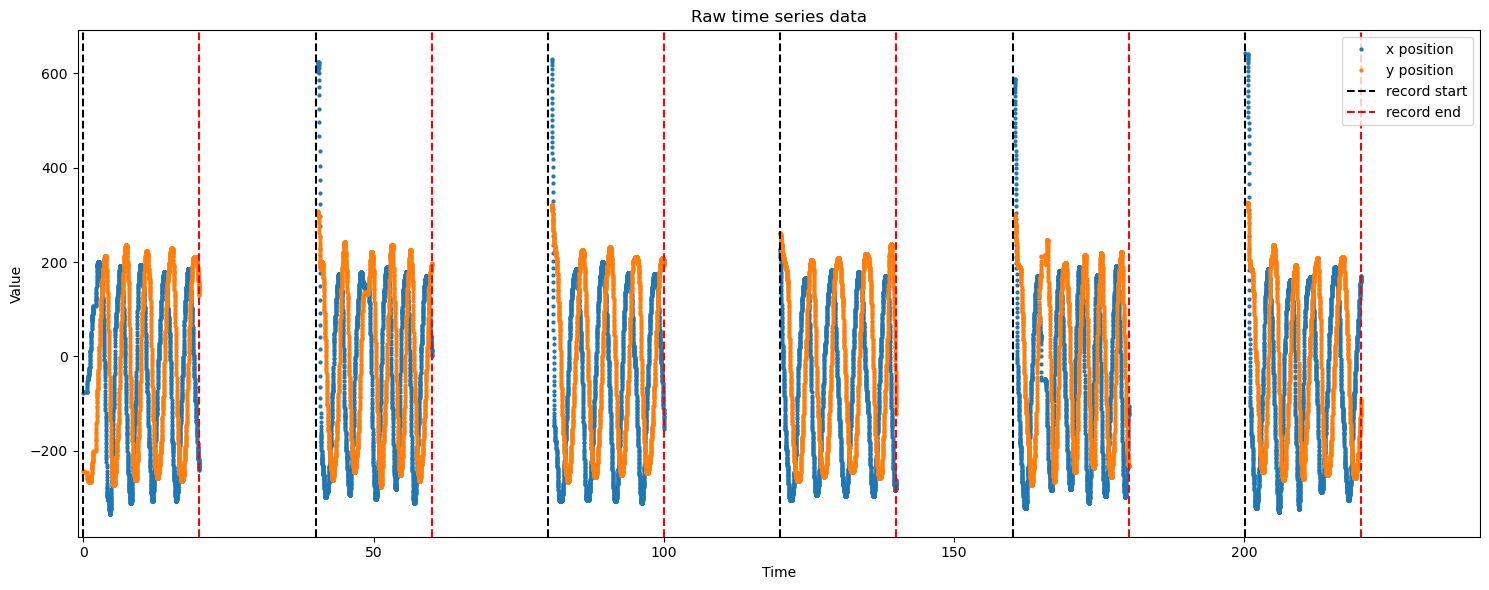


--- Processing Individual Records ---
Generating plots for Record 0...


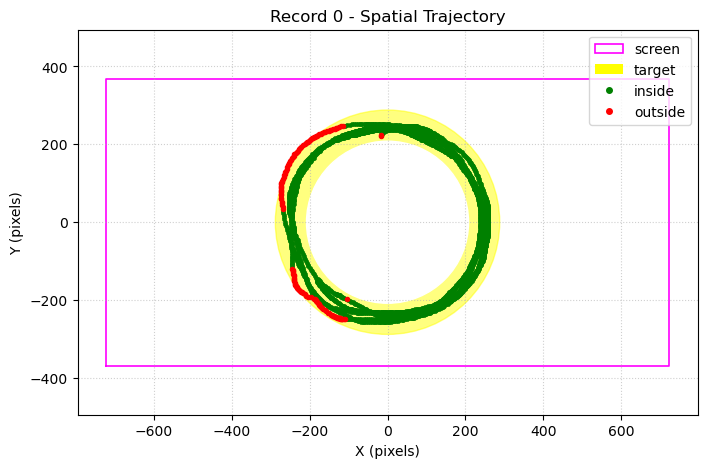

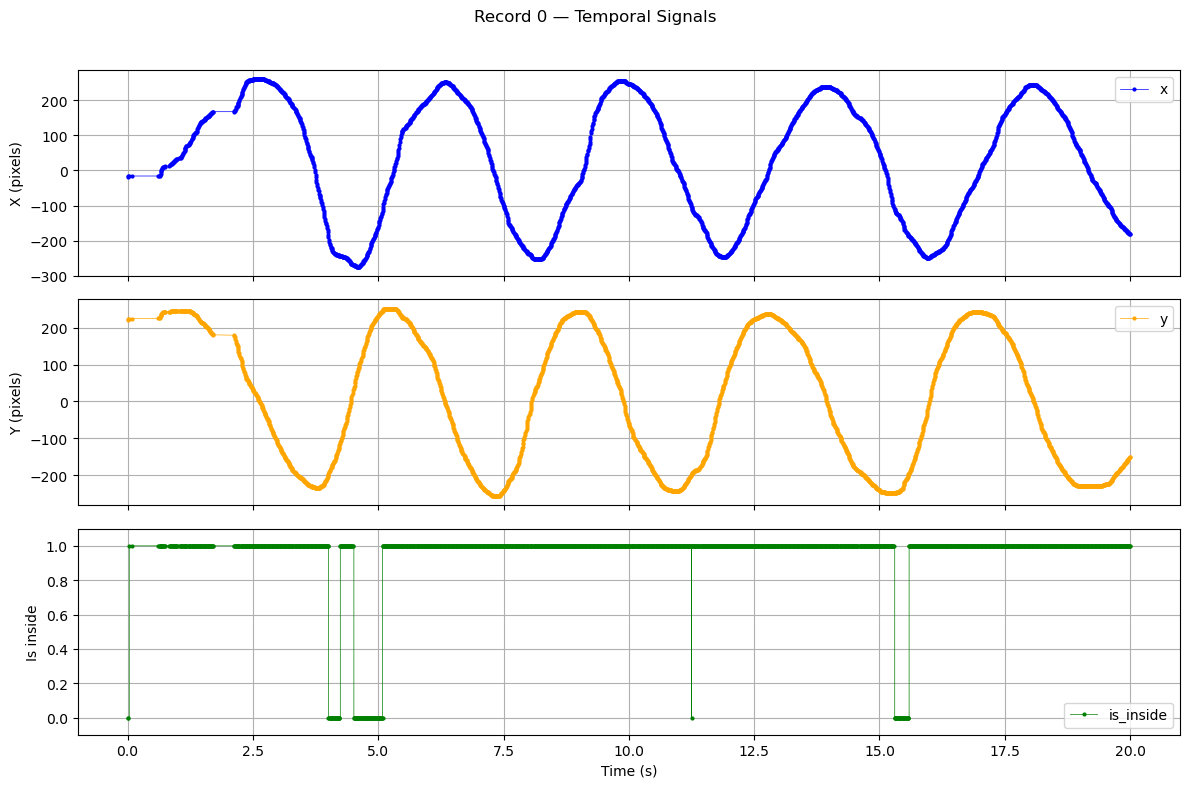

Generating plots for Record 1...


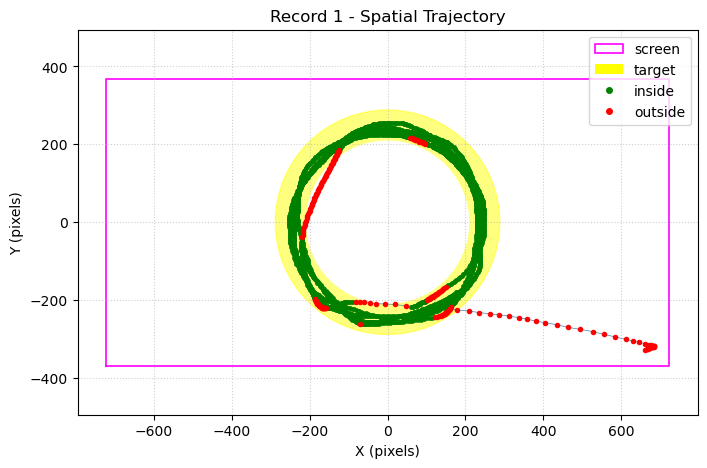

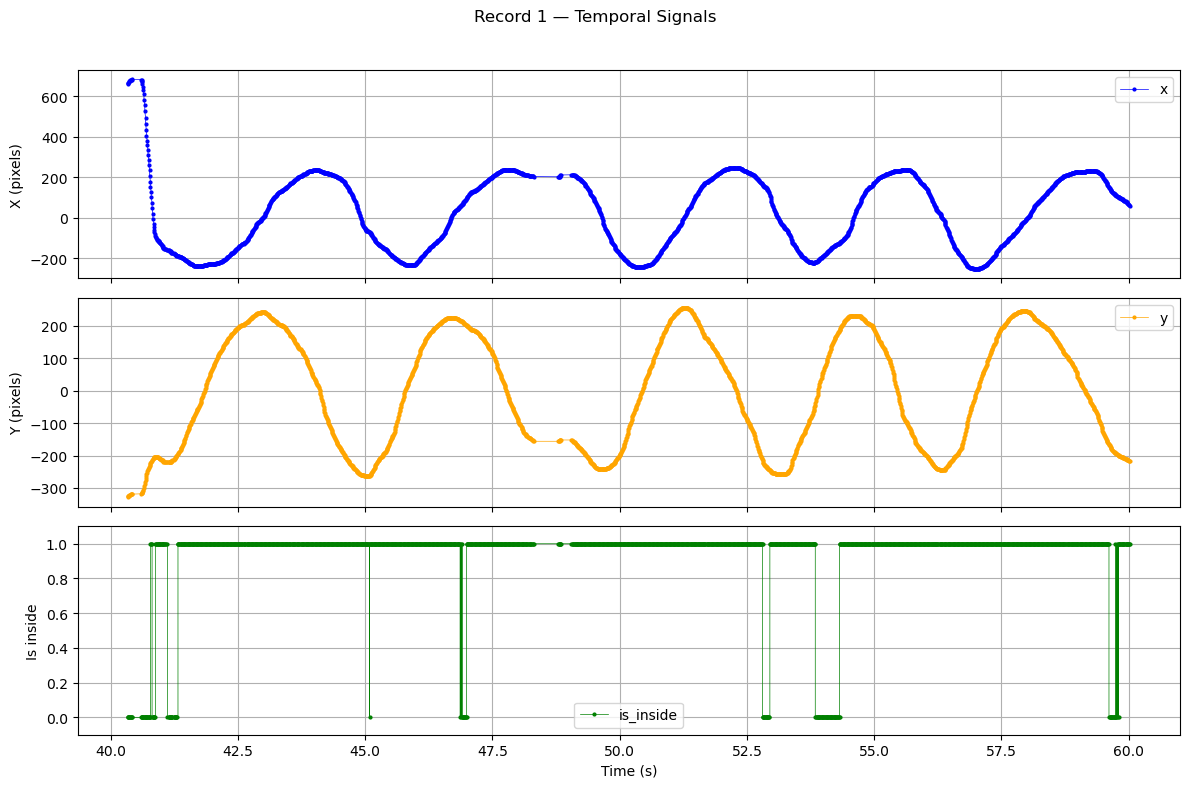

Generating plots for Record 2...


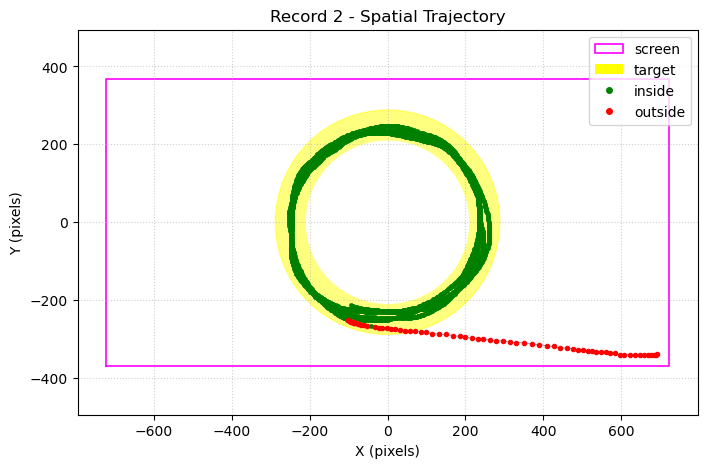

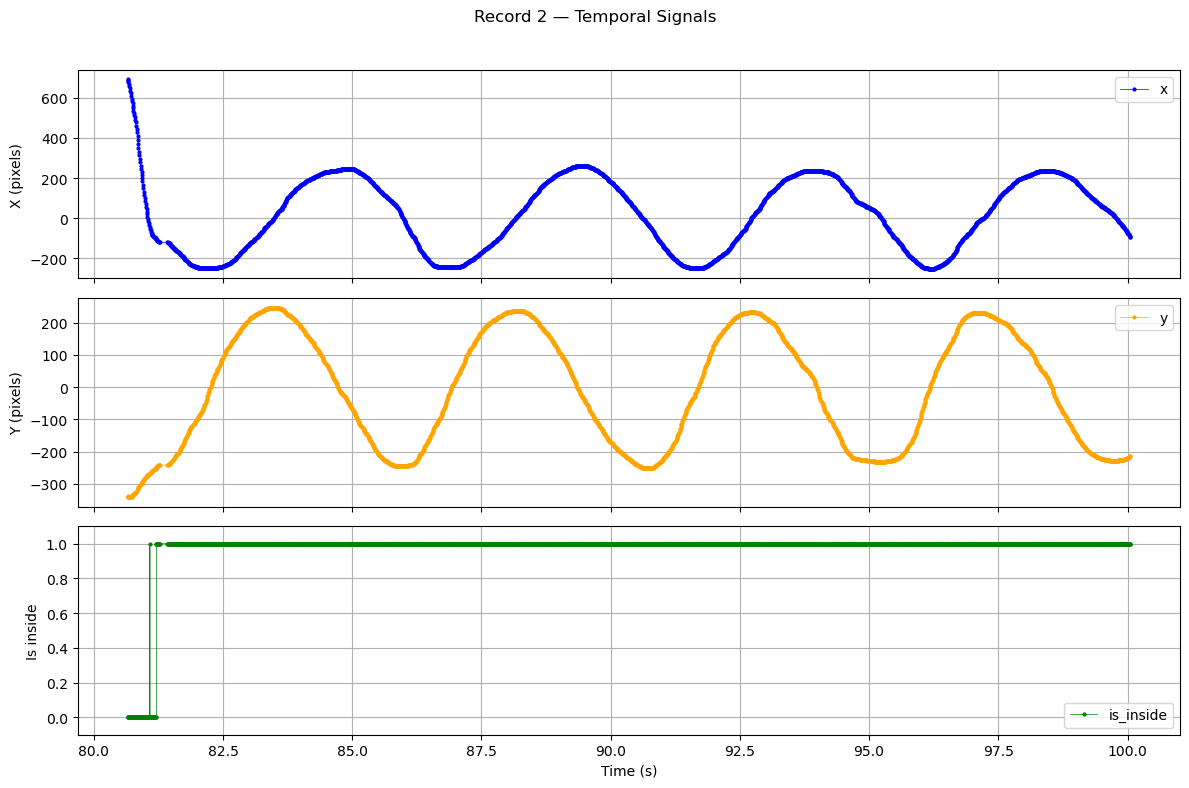

Generating plots for Record 3...


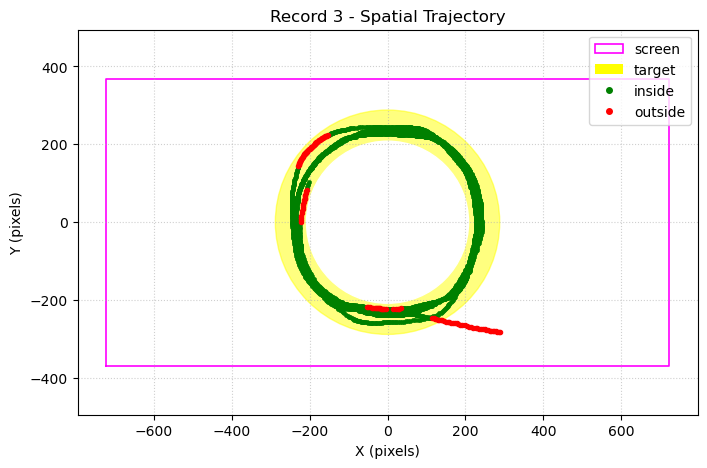

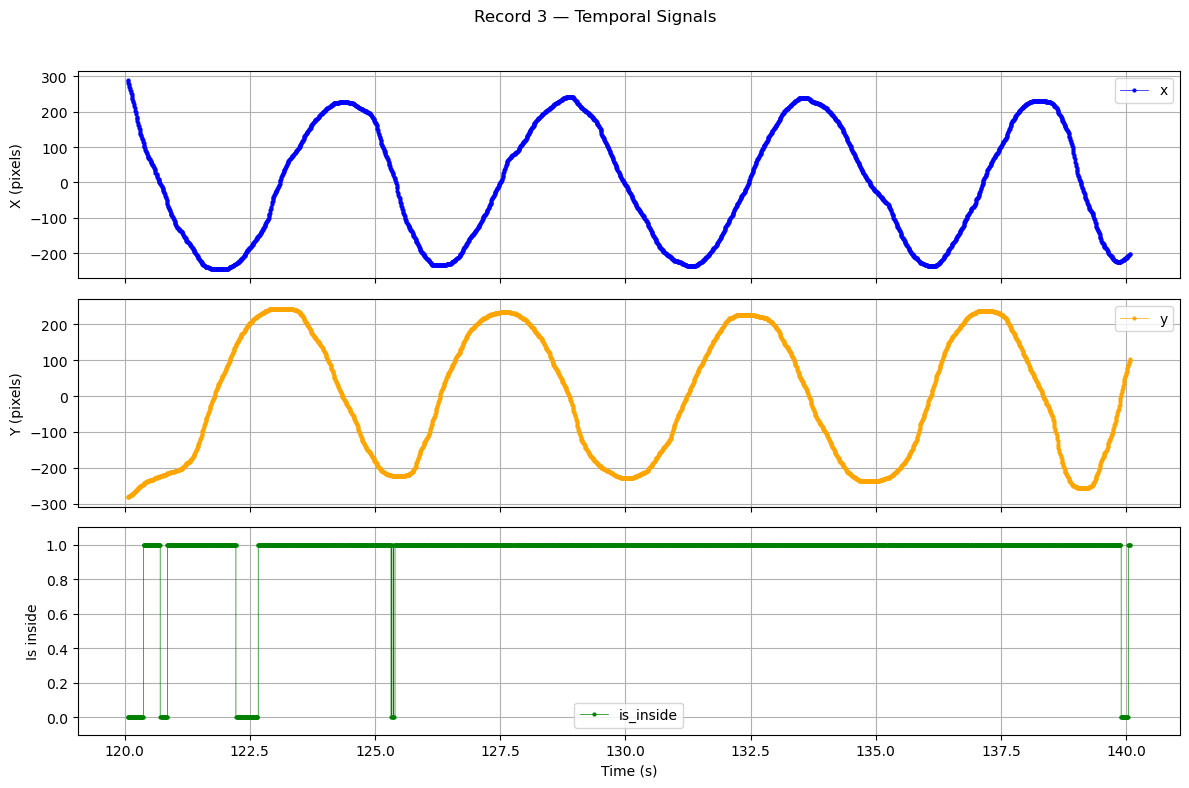

Generating plots for Record 4...


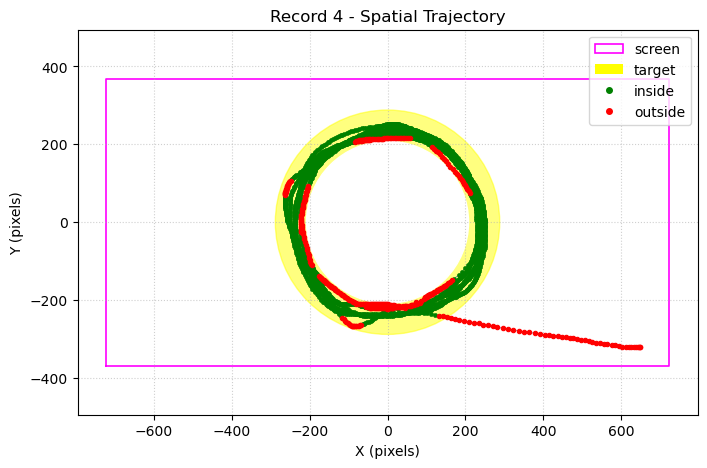

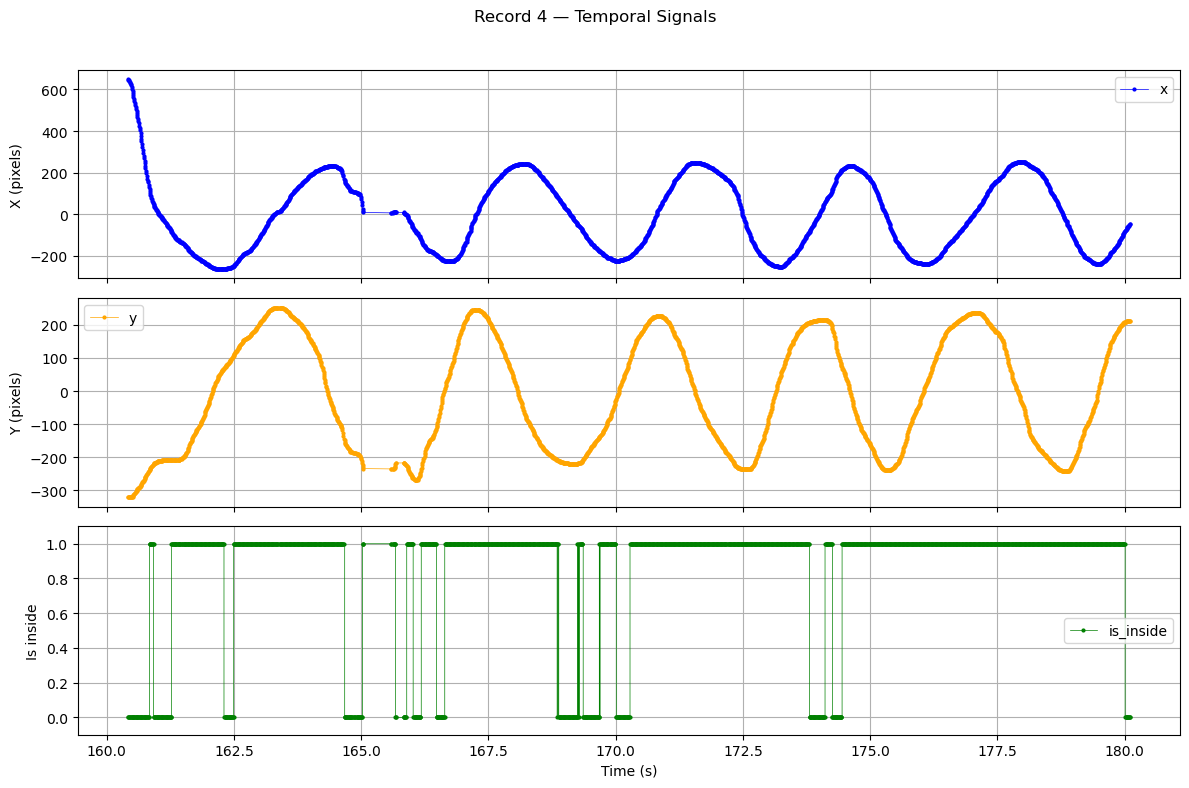

Generating plots for Record 5...


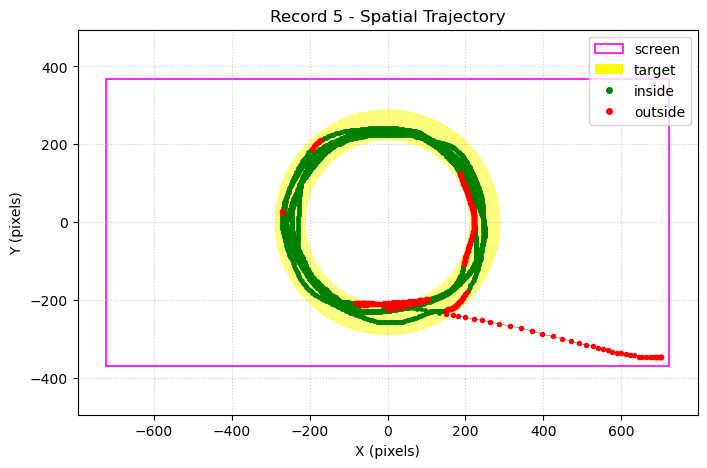

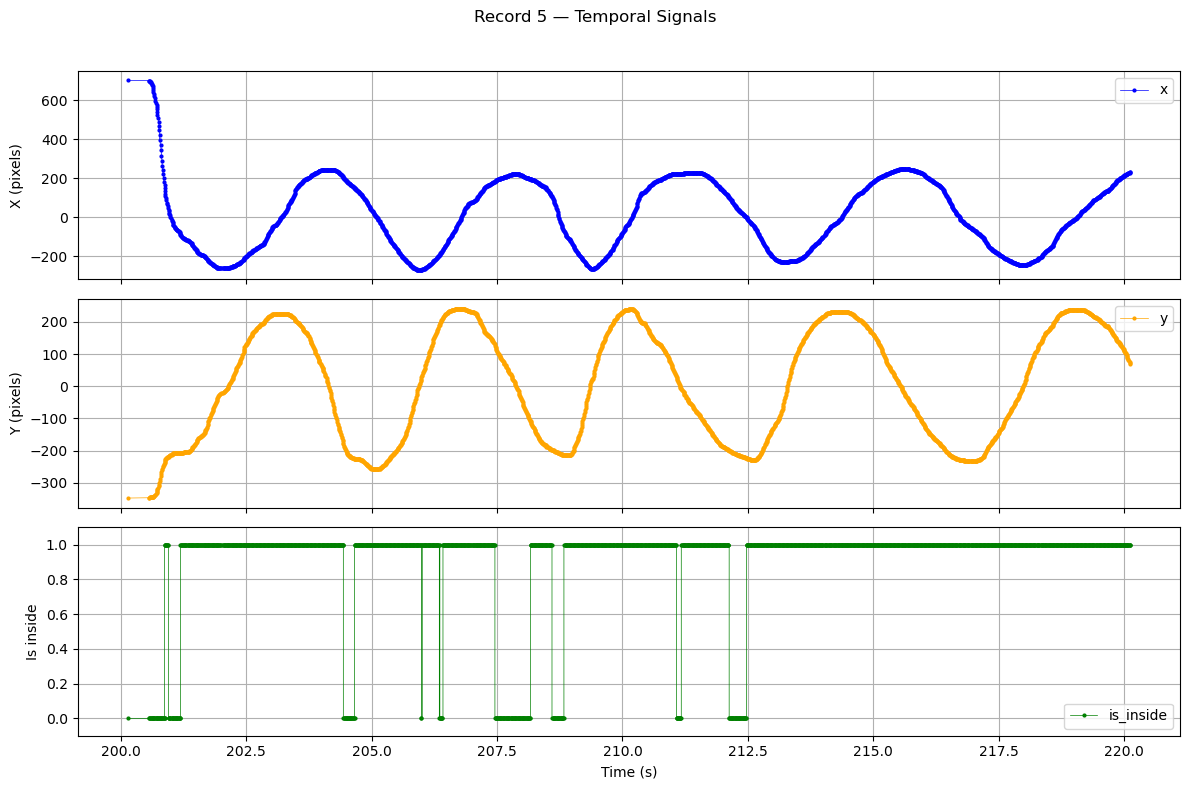


Analysis complete. Plots are displayed inline above.


In [40]:
def main() -> None:
    """Main function to run the analysis workflow."""
    try:
        header = parse_header(data_path)
        markers = parse_markers(marker_path)
        timestamps, mouse_x, mouse_y, in_target = load_data(data_path)
    except (FileNotFoundError, ValueError, RuntimeError) as e:
        print(f"An error occurred during data loading: {e}")
        return

    if timestamps.size == 0:
        print("No data was loaded. Exiting.")
        return

    print("--- Header Information ---")
    keys_to_print = [
        "screenWidth","screenHeight","cornerX","cornerY","centerX","centerY",
            "externalRadius","internalRadius","borderRadius","cursorRadius",
            "indexOfDifficulty","taskRadius","taskTolerance","autoStart",
            "cycleMaxNumber","cycleDuration","software","version","task","isWithLSL",
            "borderColor","backgroundColor","cursorColorRecord","cursorColorWait",
    ]
    for key in keys_to_print:
        if key in header:
            print(f"{key}: {header.get(key)}")
    print("-" * 28)

    t0 = timestamps[0]
    time_sec = (timestamps - t0) / 1000.0
    record_starts_sec = [(ts - t0) / 1000.0 for ts in markers["start_ts"]]
    record_ends_sec = [(ts - t0) / 1000.0 for ts in markers["end_ts"]]
    
    print("\n--- Record Durations ---")
    for i, (start, end) in enumerate(zip(record_starts_sec, record_ends_sec)):
        duration = end - start
        print(
            f"Record {i}: Start={start:.3f}s, End={end:.3f}s, Duration={duration:.3f}s"
        )
    print("-" * 30)

    plot_overall_timeseries(
        time_sec,
        mouse_x,
        mouse_y,
        record_starts_sec,
        record_ends_sec,
    )

    print("\n--- Processing Individual Records ---")
    center_x = header.get("centerX", 0)
    center_y = header.get("centerY", 0)

    for i, (start_sec, end_sec) in enumerate(zip(record_starts_sec, record_ends_sec)):
        mask = (time_sec >= start_sec) & (time_sec <= end_sec)
        if not np.any(mask):
            print(f"Warning: No data found for Record {i}.")
            continue

        record_data = {
            "time": time_sec[mask],
            "x": mouse_x[mask] - center_x,
            "y": -(mouse_y[mask] - center_y),
            "in_target": in_target[mask],
        }

        print(f"Generating plots for Record {i}...")
        plot_record_trajectory(i, record_data, header)
        plot_record_temporal(i, record_data)

    print("\nAnalysis complete. Plots are displayed inline above.")


if __name__ == "__main__":
    main()



### 3. Define variables from header for later use 

In [34]:

screenWidth  = header.get("screenWidth") 
screenHeight = header.get("screenHeight")
centerX      = header.get("centerX")
centerY      = header.get("centerY")
cornerX      = header.get("cornerX")
cornerY      = header.get("cornerY")
externalRadius = header.get("externalRadius")
internalRadius = header.get("internalRadius")
borderRadius   = header.get("borderRadius")
cursorRadius   = header.get("cursorRadius")
indexOfDifficulty = header.get("indexOfDifficulty")
taskRadius      = header.get("taskRadius")
tasktolerance   = header.get("taskTolerance")
autoStart      = header.get("autoStart")
cycleMaxNumber = header.get("cycleMaxNumber")
cycleDuration  = header.get("cycleDuration")

### 4. Loading the data file (t, x, y, in_target) and array conversion

In [35]:
timestamps, mouseX, mouseY, in_target = [], [], [], []

with open(data_path, "r") as f:
    reader = csv.reader(f, delimiter=';')  # ou ',' selon ton fichier
    rows = list(reader)

for r in rows:
    if len(r) >= 1 and ',' in r[0]:
        parts = r[0].split(',')
        if len(parts) >= 4:  # timestamp, X, Y, in_target
            try:
                t = float(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                flag = int(float(parts[3]))  # 1 ou 0
                timestamps.append(t)
                mouseX.append(x)
                mouseY.append(y)
                in_target.append(flag)
            except ValueError:
                continue

# array conversion
timestamps = np.array(timestamps)
mouseX = np.array(mouseX)
mouseY = np.array(mouseY)
in_target = np.array(in_target)

### 5. Computing normalized time vectors

In [36]:
# Time conversion (seconds)
time = (timestamps - timestamps[0]) / 1000.0

# Time normalization based on record start/end
t0 = min(record_start_raw + record_end_raw)
record_start_sec = [(t - t0) / 1000.0 for t in record_start_raw]
record_end_sec  = [(t - t0) / 1000.0 for t in record_end_raw]

### 6. Processing marker events and duration extraction

In [37]:
def compute_task_duration(marker_path, record_start_sec, record_end_sec):

    # Read marker file again for processing
    with open(marker_path, "r") as f:
        lines = f.readlines()

    record_start_raw, record_end_raw, timestamp_all = [], [], []

    # Timestamp extraction
    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 3:
            continue
        try:
            ts = int(parts[1])
            timestamp_all.append(ts)
        except ValueError:
            continue

        if "DoCycleChange:DoRecord" in line:
            record_start_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_end_raw.append(ts)

    # Verifications
    if len(record_start_raw) == 0:
        raise ValueError("No ‘DoRecord’ event detected in the file.")
    if len(record_end_raw) == 0:
        raise ValueError("No ‘DoPause’ event detected in the file.")
    if len(record_start_raw) != len(record_end_raw):
        print("Number of starts and ends does not match.")

    # Duration calculation for each task
    task_durations = []
    for start, end in zip(record_start_sec, record_end_sec):
        duration = end - start
        task_durations.append(duration)

    # Output results
    print("Start times (s):", record_start_sec)
    print("End times (s):", record_end_sec)
    print("Duration (s):", task_durations)

    # Detailed summary
    print("\nSummary:")
    for i, (start, end, dur) in enumerate(zip(record_start_sec, record_end_sec, task_durations), start=1):
        print(f"Task {i}: start = {start:.2f}s, end = {end:.2f}s, duration = {dur:.2f}s")

    return

compute_task_duration(marker_path, record_start_sec, record_end_sec)


Start times (s): [0.0, 40.026, 80.053, 120.076, 160.104, 200.131]
End times (s): [20.013, 60.04, 100.062, 140.09, 180.12, 220.134]
Duration (s): [20.013, 20.013999999999996, 20.009, 20.01400000000001, 20.01599999999999, 20.002999999999986]

Summary:
Task 1: start = 0.00s, end = 20.01s, duration = 20.01s
Task 2: start = 40.03s, end = 60.04s, duration = 20.01s
Task 3: start = 80.05s, end = 100.06s, duration = 20.01s
Task 4: start = 120.08s, end = 140.09s, duration = 20.01s
Task 5: start = 160.10s, end = 180.12s, duration = 20.02s
Task 6: start = 200.13s, end = 220.13s, duration = 20.00s


### 7. Preprocessing and record-by-record visualization

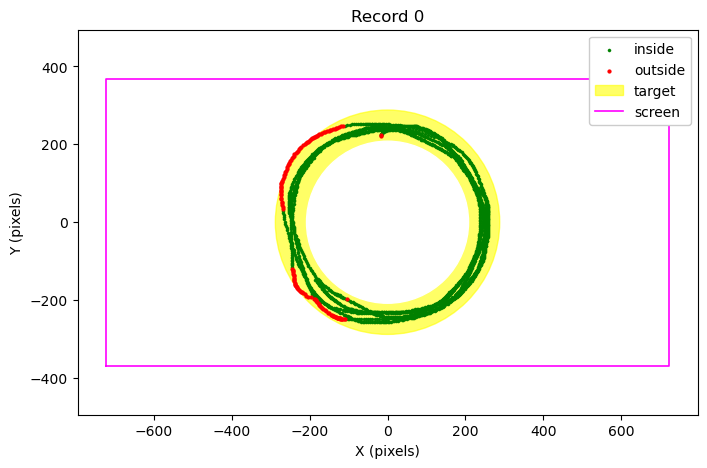

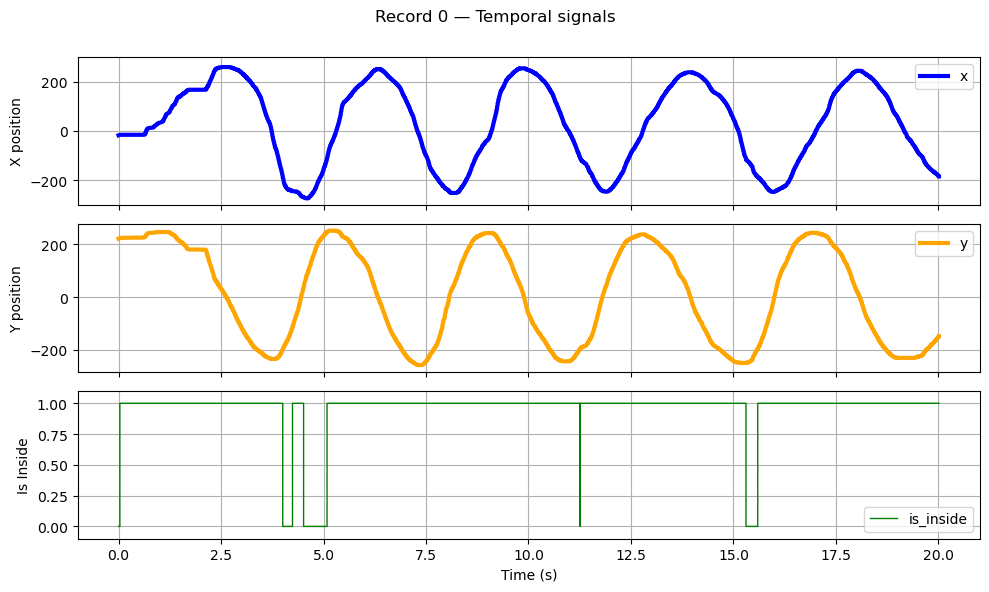

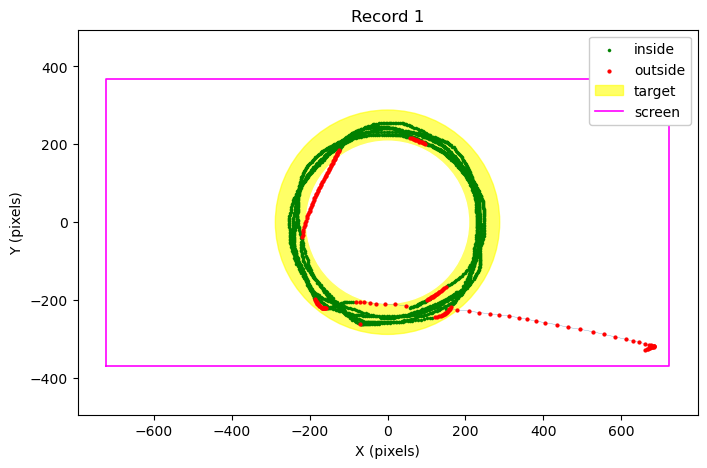

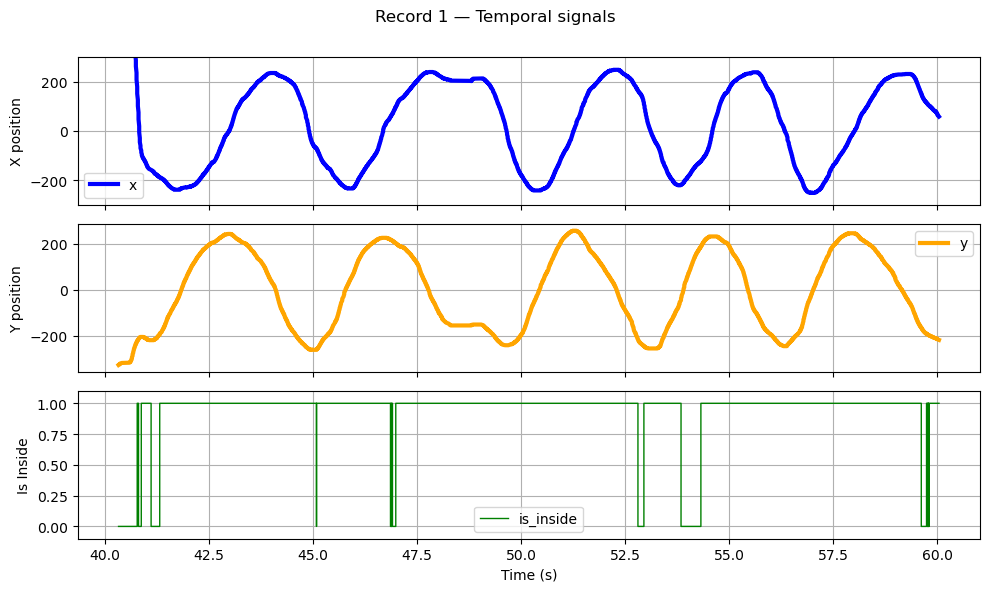

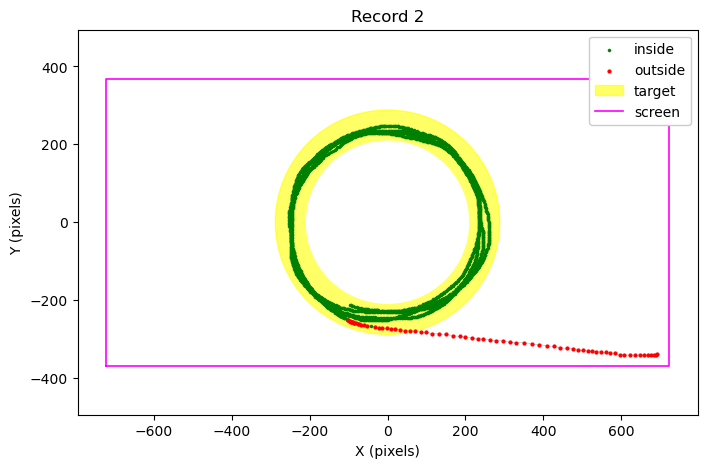

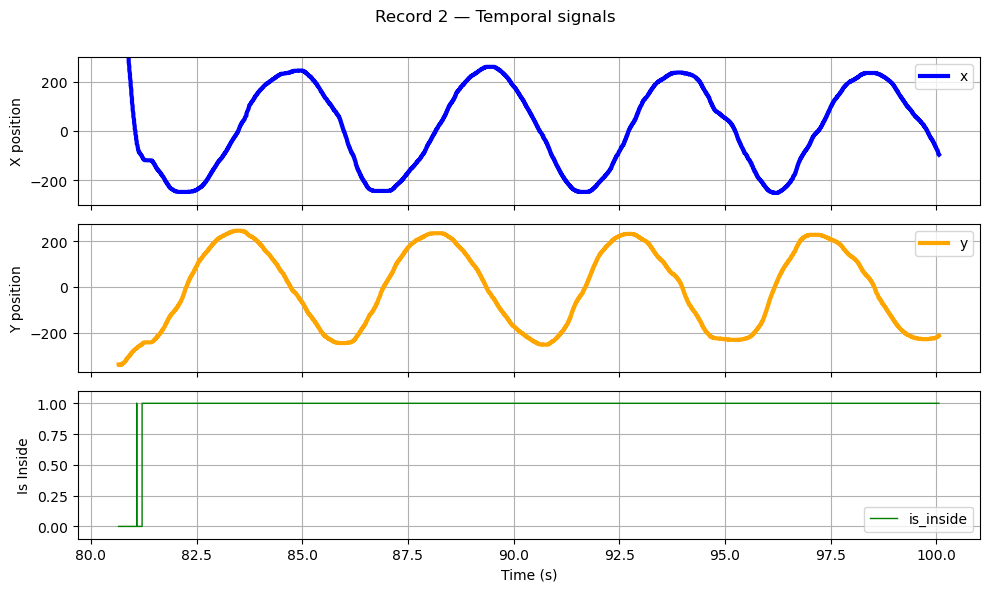

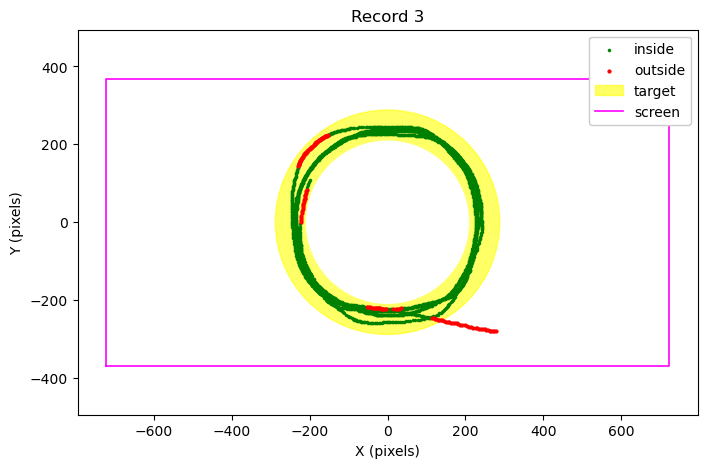

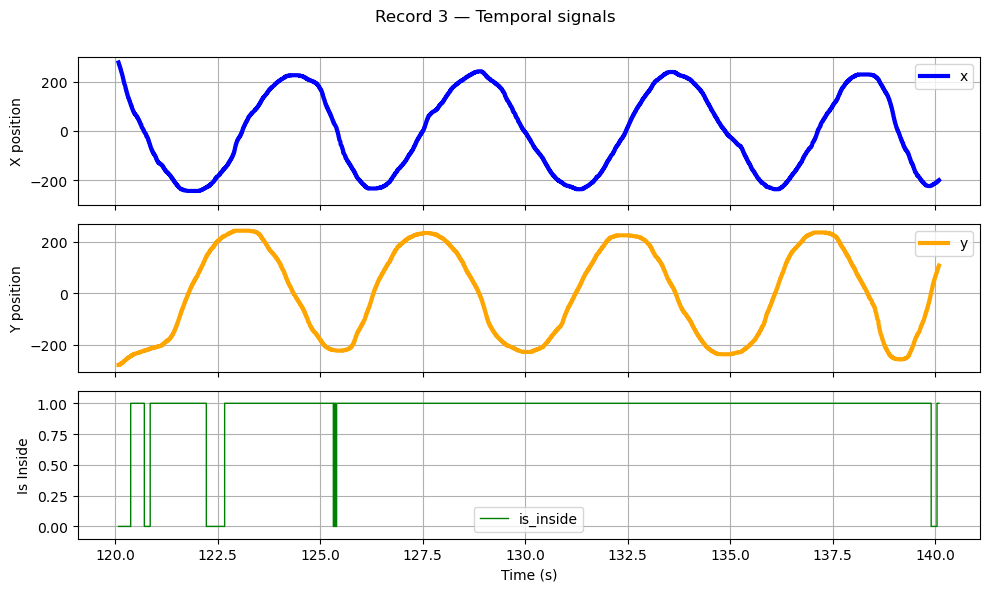

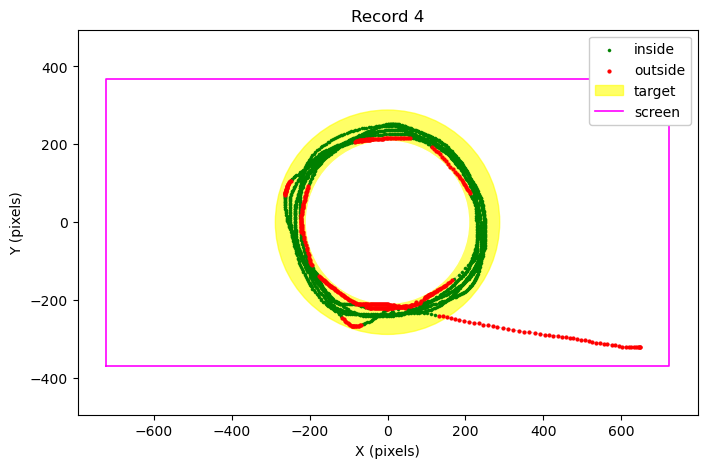

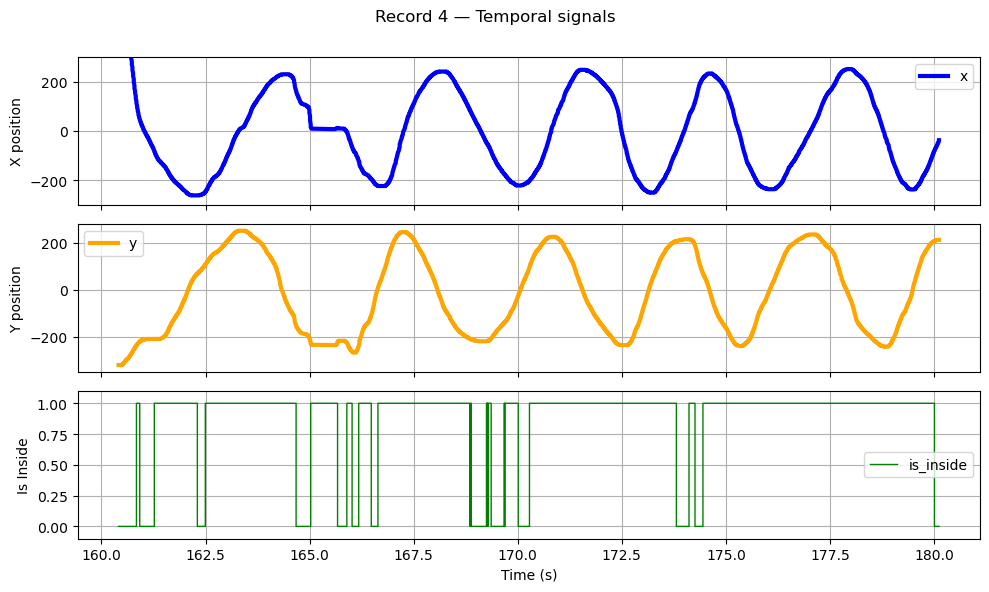

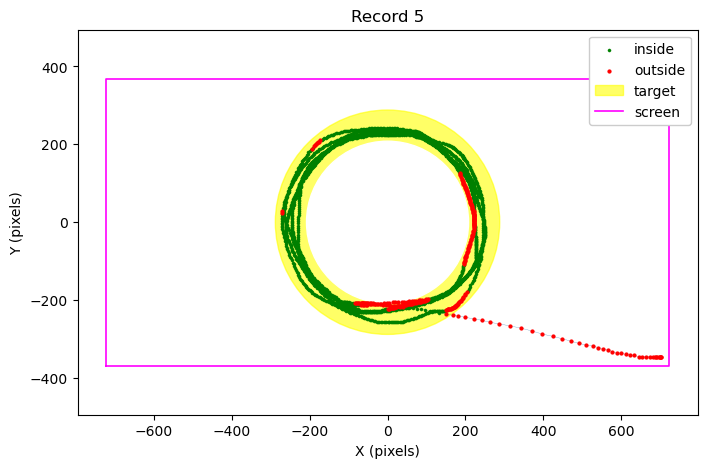

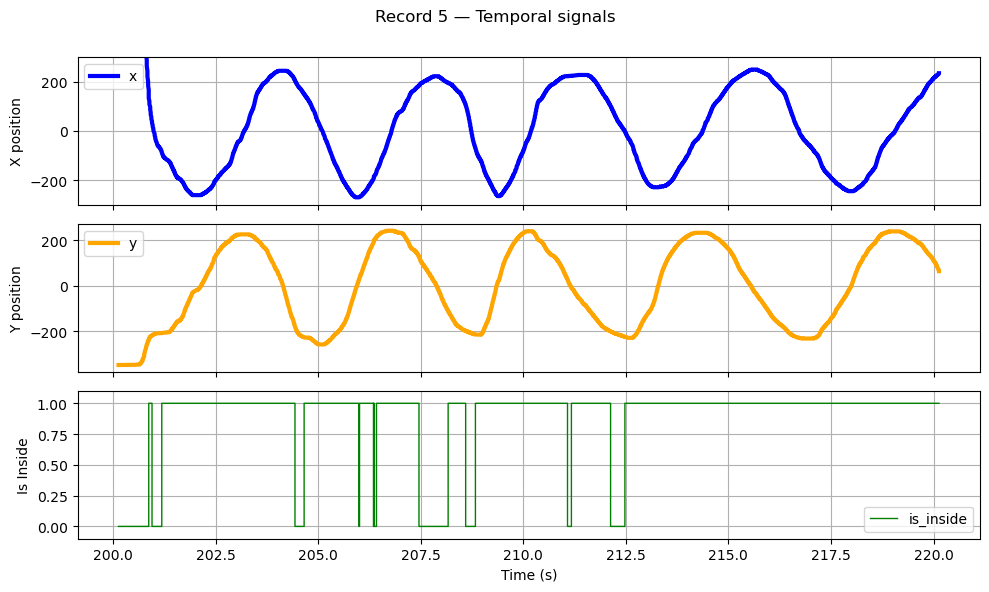

In [38]:
# Normalization of lengths to avoid error
m = min(len(time), len(mouseX), len(mouseY), len(in_target))
time = time[:m]
mouseX = mouseX[:m]
mouseY = mouseY[:m]
in_target = in_target[:m]

# Principal loop over records
records_data = []

for i, (start, end) in enumerate(zip(record_start_sec, record_end_sec), start=0):
    mask = (time >= start) & (time <= end)
    x_task = mouseX[mask] - centerX
    y_task = -(mouseY[mask] - centerY)
    t_task = time[mask]
    in_task = in_target[mask]

    records_data.append({
        "record": i,
        "time": t_task,
        "x": x_task,
        "y": y_task,
        "in_target": in_task
    })

    # ======================================================
    # Spatial plot (trajectory + target)
    # ======================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(x_task, y_task, '-', color='steelblue', label=None, zorder=2, lw=0.2)
    ax1.scatter(x_task[in_task == 1], y_task[in_task == 1],
                color='green', s=5, label='inside', zorder=3, lw=0.3)
    ax1.scatter(x_task[in_task == 0], y_task[in_task == 0],
                color='red', s=5, label='outside', zorder=3, lw=0.8)

    # Target (ring)
    circle_outer = plt.Circle((0, 0), externalRadius, color='yellow', alpha=0.6, zorder=1, label='target')
    circle_inner = plt.Circle((0, 0), internalRadius, color='white', zorder=2)
    ax1.add_patch(circle_outer)
    ax1.add_patch(circle_inner)

    # Screen border
    ax1.plot([-screenWidth/2, screenWidth/2, screenWidth/2, -screenWidth/2, -screenWidth/2],
             [-screenHeight/2, -screenHeight/2, screenHeight/2, screenHeight/2, -screenHeight/2],
             color='magenta', lw=1.2, label='screen', zorder=0)

    ax1.set_title(f"Record {i}")
    ax1.set_xlabel("X (pixels)")
    ax1.set_ylabel("Y (pixels)")
    ax1.axis("equal")
   # ax1.set_xlim(-600, 600)
    #ax1.set_ylim(-400, 400)
    ax1.legend(loc='upper right', framealpha=1, facecolor='white')
    ax1.grid(False)
    plt.show()

    # ======================================================
    # Temporal plot (X, Y, Inside)
    # ======================================================
    fig2, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig2.suptitle(f"Record {i} — Temporal signals")

    # X
    axes[0].plot(t_task, x_task, color='blue', label='x', lw=3)
    axes[0].set_ylabel("X position")
    axes[0].set_ylim(-300, 300)
    axes[0].legend()
    axes[0].grid(True)

    # Y
    axes[1].plot(t_task, y_task, color='orange', label='y', lw=3)
    axes[1].set_ylabel("Y position")
    axes[0].set_ylim(-300, 300)
    axes[1].legend()
    axes[1].grid(True)

    # Inside
    axes[2].step(t_task, in_task, where='post', color='green', label='is_inside', lw=1)
    axes[2].set_ylabel("Is Inside")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


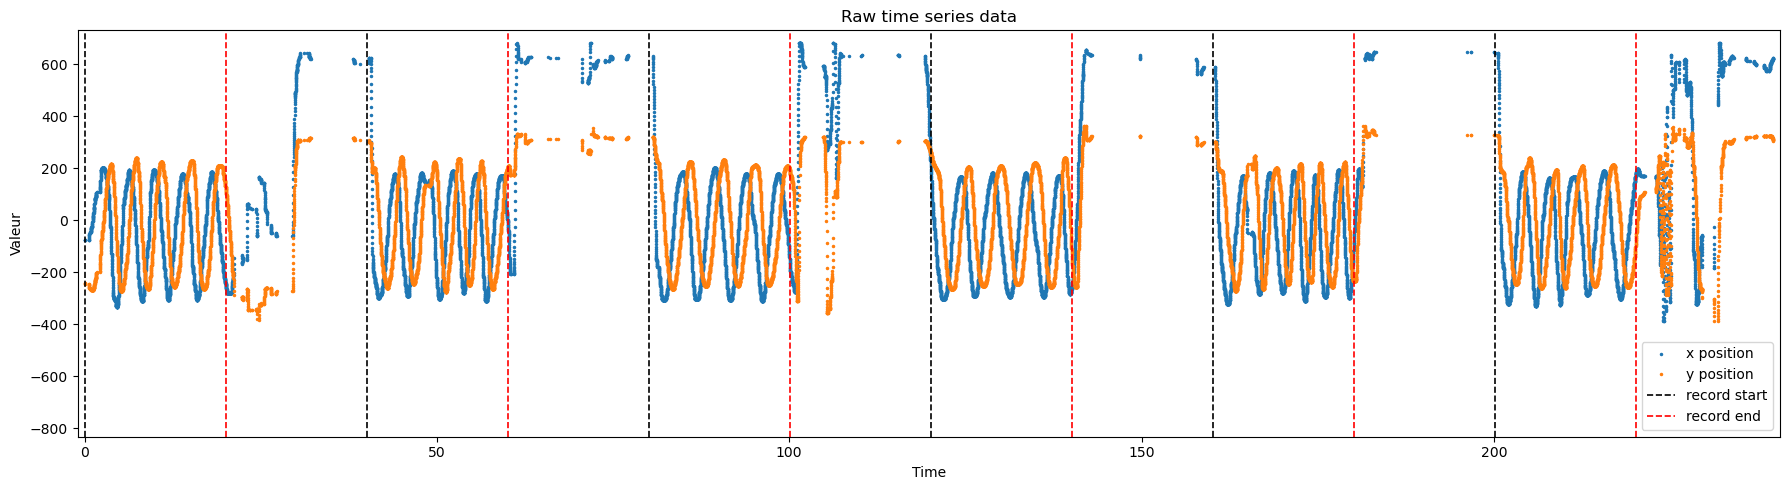

In [39]:
# --- Création des 5 graphes ---
plt.figure(figsize=(18, 5))

# --- Tracé des positions centrées (points pour lisibilité fine) ---
plt.plot(time, mouseX - np.mean(mouseX), '.', ms=3, color='tab:blue', label='x position')
plt.plot(time, mouseY - np.mean(mouseY), '.', ms=3, color='tab:orange', label='y position')

# --- Marqueurs de début et fin d’enregistrement ---
for s in record_start_sec:
    plt.axvline(s, color='black', linestyle='--', linewidth=1.2, label='record start' if s == record_start_sec[0] else "")
for e in record_end_sec:
    plt.axvline(e, color='red', linestyle='--', linewidth=1.2, label='record end' if e == record_end_sec[0] else "")

# --- Ajustements visuels ---
plt.xlim(min(time[0], record_start_sec[0]) - 1, max(time[-1], record_end_sec[-1]) + 1)
plt.ylim(np.min([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) - 50, np.max([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) + 50)

plt.xlabel("Time")
plt.ylabel("Valeur")
plt.title("Raw time series data")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()